<a href="https://colab.research.google.com/github/rianeps/rianeps/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing the Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_validate, StratifiedKFold

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import graphviz
import warnings
warnings.filterwarnings('ignore')

## Importing the Data

In [4]:
data = pd.read_excel("/content/drive/MyDrive/Samatrix Project/credit_card.xls")
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Data Cleaning

In [5]:
data['Bill_AMT_AVG'] = data.iloc[:, 12:19].mean(axis = 1).round(2)

In [6]:
data['PAY_AMT_AVG'] = data.iloc[:, 19:26].mean(axis = 1).round(2)

In [7]:
data['Bill_AMT_AVG']

0          1100.57
1          2439.57
2         14738.71
3         33333.43
4         15905.57
           ...    
29995    104835.57
29996      3288.43
29997     10070.86
29998     50358.71
29999     33278.86
Name: Bill_AMT_AVG, Length: 30000, dtype: float64

In [8]:
data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month', 'Bill_AMT_AVG', 'PAY_AMT_AVG'],
      dtype='object')

## Data Preprocessing

In [9]:
data = data.drop(['ID', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'], axis = 1)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  int64  
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  default payment next month  30000 non-null  int64  
 12  Bill_AMT_AVG                30000 non-null  float64
 13  PAY_AMT_AVG                 300

In [11]:
data.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default payment next month,Bill_AMT_AVG,PAY_AMT_AVG
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,0.221200,39360.750253,9335.540503
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,0.415062,54816.226936,12556.810743
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,0.000000,-47908.710000,-5253.900000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,4581.497500,2048.407500
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18769.000000,5156.805000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50107.430000,11890.050000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,1.000000,759238.140000,453055.140000


In [12]:
data.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default payment next month',
       'Bill_AMT_AVG', 'PAY_AMT_AVG'],
      dtype='object')

In [13]:
data.rename(columns = {"PAY_0": "PAY_1"}, inplace = True )
data.rename(columns = {"default payment next month": "default"}, inplace = True )

In [14]:
cat = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default']

In [15]:
for i in cat:
    data[i] = data[i].astype('category')

In [16]:
for i in cat:
    print(i, data[i].unique())

SEX [2, 1]
Categories (2, int64): [1, 2]
EDUCATION [2, 1, 3, 5, 4, 6, 0]
Categories (7, int64): [0, 1, 2, 3, 4, 5, 6]
MARRIAGE [1, 2, 3, 0]
Categories (4, int64): [0, 1, 2, 3]
PAY_1 [2, -1, 0, -2, 1, ..., 4, 8, 7, 5, 6]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_2 [2, 0, -1, -2, 3, ..., 7, 4, 1, 6, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_3 [-1, 0, 2, -2, 3, ..., 6, 7, 1, 5, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_4 [-1, 0, -2, 2, 3, ..., 5, 7, 6, 1, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_5 [-2, 0, -1, 2, 3, 5, 4, 7, 8, 6]
Categories (10, int64): [-2, -1, 0, 2, ..., 5, 6, 7, 8]
PAY_6 [-2, 2, 0, -1, 3, 6, 4, 7, 8, 5]
Categories (10, int64): [-2, -1, 0, 2, ..., 5, 6, 7, 8]
default [1, 0]
Categories (2, int64): [0, 1]


In [17]:
data['EDUCATION'].replace({0:4, 5:4, 6:4}, inplace = True)
data.EDUCATION.value_counts()

2    14030
1    10585
3     4917
4      468
Name: EDUCATION, dtype: int64

In [18]:
data['MARRIAGE'].replace({0:3}, inplace = True)
data.MARRIAGE.value_counts()

2    15964
1    13659
3      377
Name: MARRIAGE, dtype: int64

In [19]:
data['SEX'].replace({1:0, 2: 1}, inplace = True)
data.SEX.value_counts()

1    18112
0    11888
Name: SEX, dtype: int64

## Exploratory Data Analysis

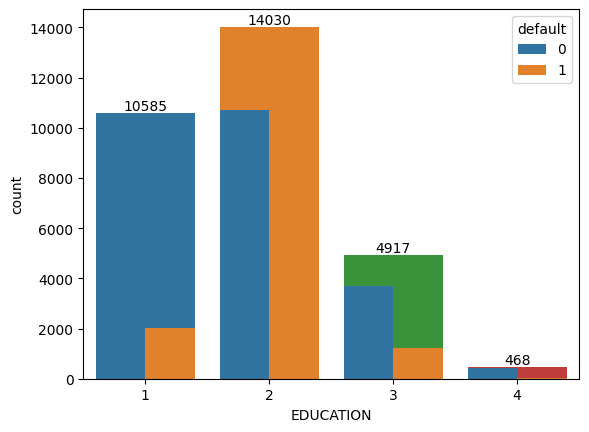

In [20]:
counts = data['EDUCATION'].value_counts().sort_index().to_dict()

sns.countplot(x = 'EDUCATION', data = data)
sns.countplot(x = 'EDUCATION', data = data, hue = data.default)

for i, count in enumerate(counts.values()):
    plt.annotate(str(count), xy = (i, count), ha = 'center', va = 'bottom')

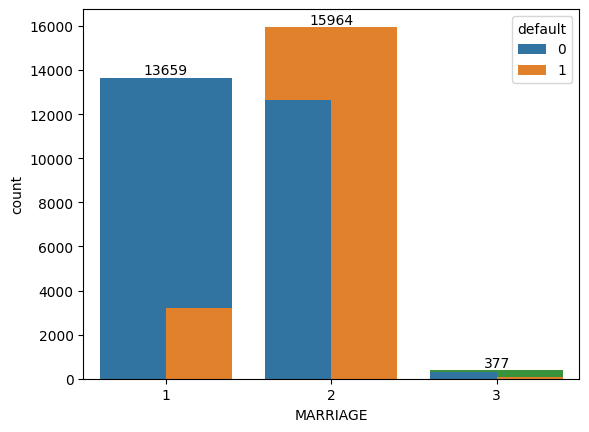

In [21]:
counts = data['MARRIAGE'].value_counts().sort_index().to_dict()

sns.countplot(x = 'MARRIAGE', data = data)
sns.countplot(x = 'MARRIAGE', data = data, hue = data.default)

for i, count in enumerate(counts.values()):
    plt.annotate(str(count), xy = (i, count), ha = 'center', va = 'bottom')

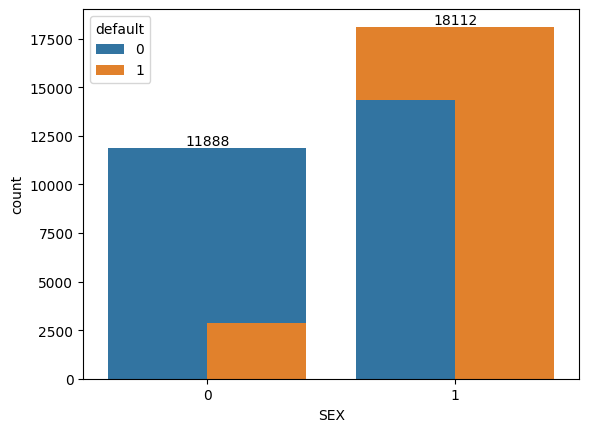

In [22]:
counts = data['SEX'].value_counts().sort_index().to_dict()

sns.countplot(x = 'SEX', data = data)
sns.countplot(x = 'SEX', data = data, hue = data.default)

for i, count in enumerate(counts.values()):
    plt.annotate(str(count), xy = (i, count), ha = 'center', va = 'bottom')

<Axes: >

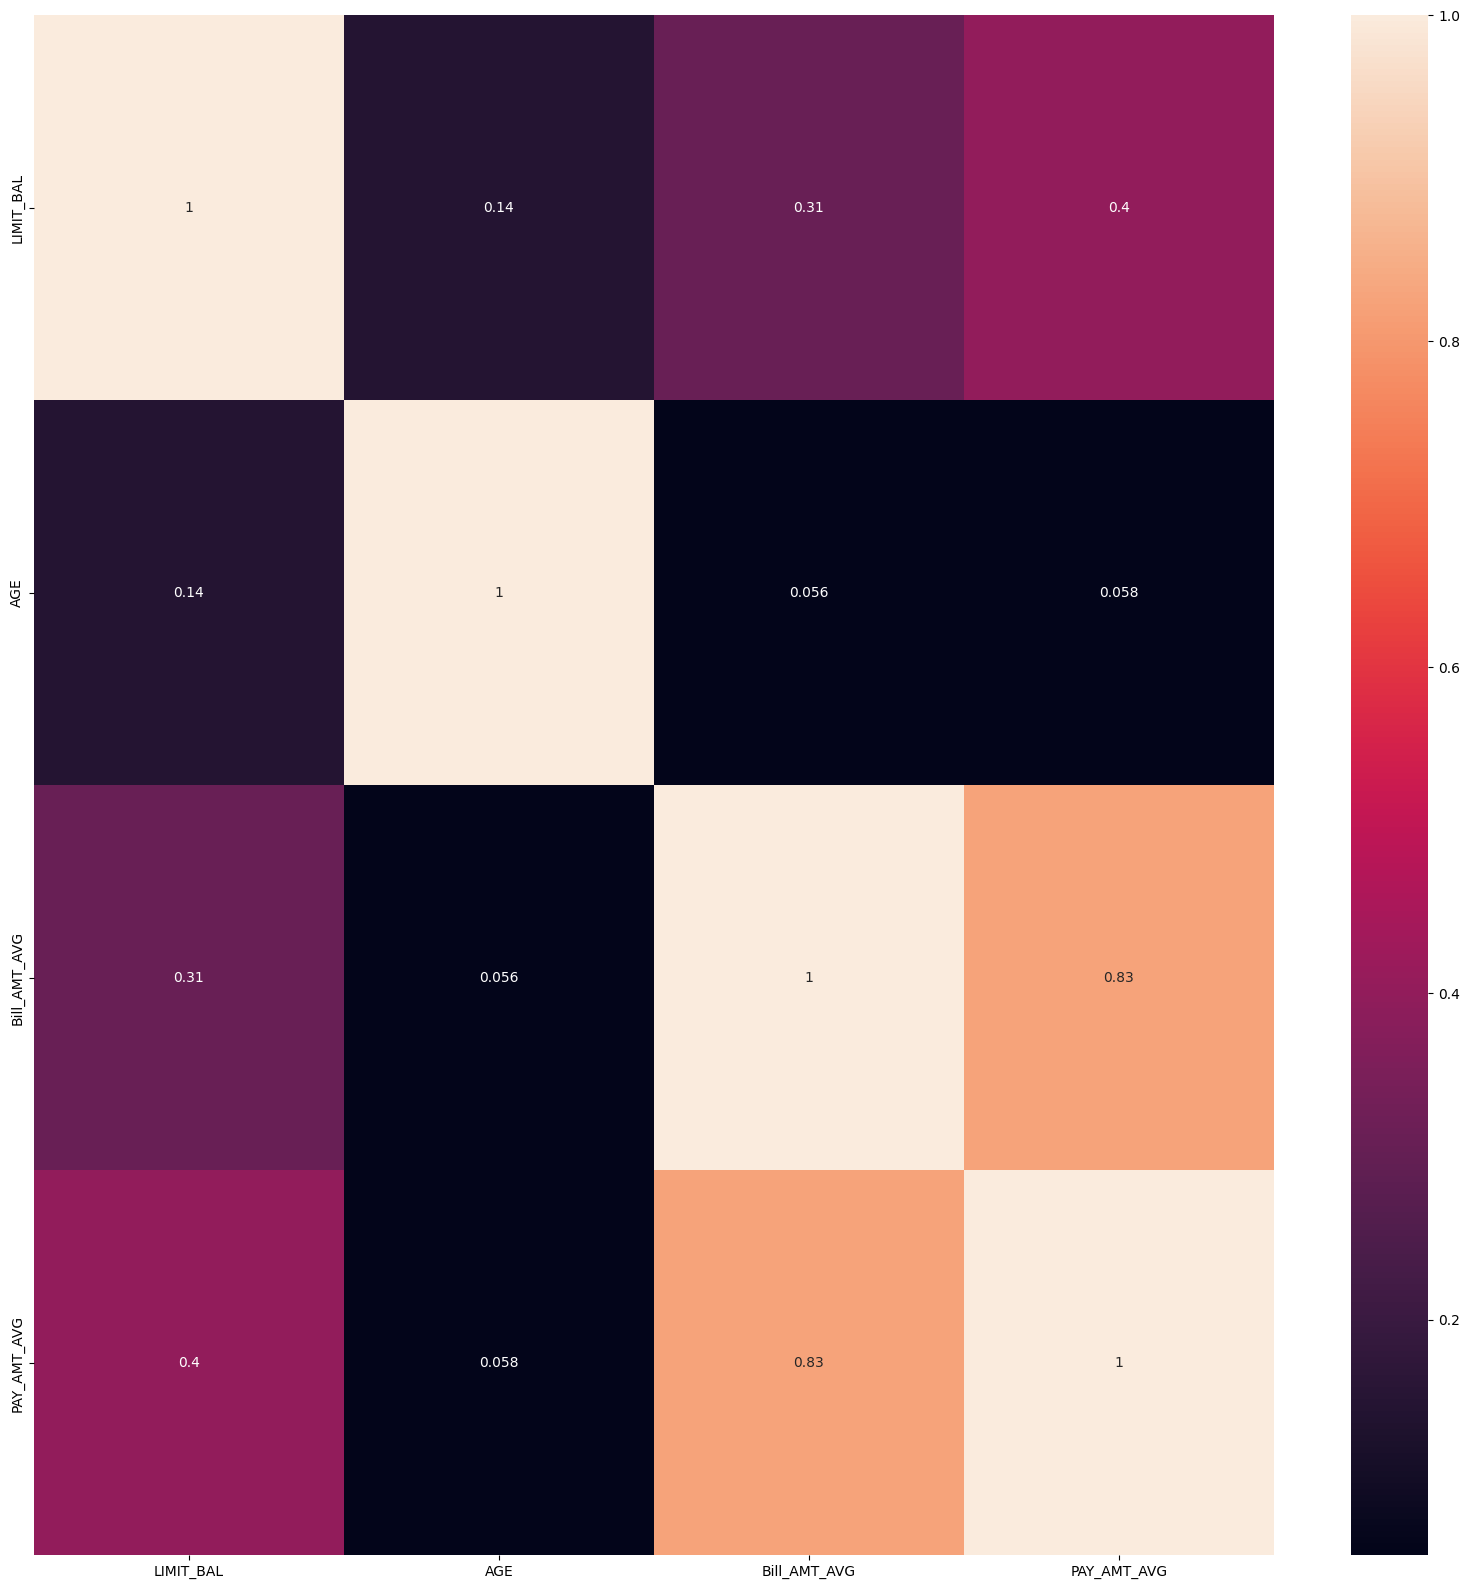

In [23]:
plt.figure(figsize = (20, 20))
sns.heatmap(data.corr(), annot = True)

In [24]:
X = data.drop(['default'], axis = 1)
y = data['default']

In [25]:
sc = StandardScaler()
X = sc.fit_transform(X)

## Splitting the training data and test data

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

In [27]:
data['default'].value_counts()

0    23364
1     6636
Name: default, dtype: int64

Proportion of variance explained by the first two principal components: 0.5126119466881962


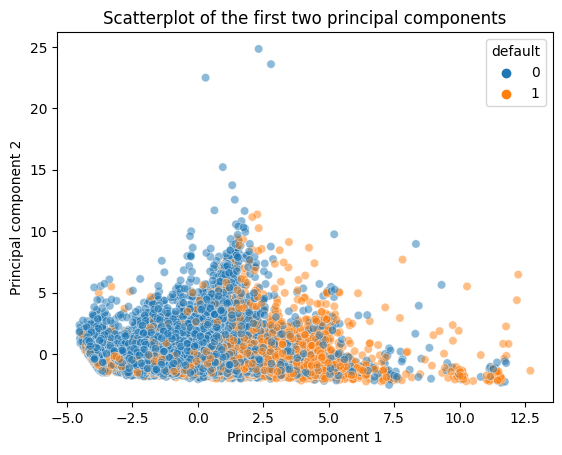

In [28]:
pca = PCA(n_components=2)
X_pca = pd.DataFrame(pca.fit_transform(X))
print(f'Proportion of variance explained by the first two principal components: {sum(pca.explained_variance_ratio_)}')

sns.scatterplot(x=X_pca[0], y=X_pca[1], hue=data['default'], alpha=0.5)
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.title('Scatterplot of the first two principal components')
plt.show()

## Building the model

### Decision Tree Classfier

0.8178888888888889


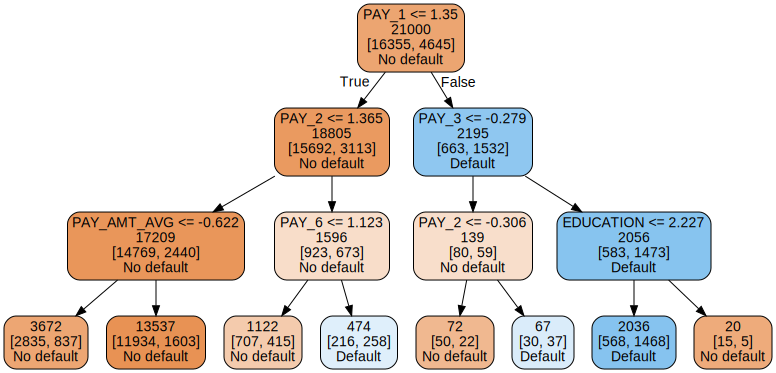

In [29]:
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)
y_pred_dtree = tree.predict(X_test)
print(accuracy_score(y_pred_dtree, y_test))
plot_data = export_graphviz(tree, feature_names=data.drop(['default'], axis = 1).columns, class_names=['No default', 'Default'], label=None, impurity=False, rounded=True, filled=True)
graph = graphviz.Source(plot_data, format="svg")
graph

### Random Forest Classifer


In [30]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8237777777777778


### Logistic Regression

In [31]:
model_log_reg = LogisticRegression()
model_log_reg.fit(X_train, y_train)

y_pred_log_reg = model_log_reg.predict(X_test)
print(accuracy_score(y_test, y_pred_log_reg))

0.8082222222222222


### SVM

In [32]:
model_svm = SVC(kernel = 'rbf', probability = True)
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)
print(accuracy_score(y_test, y_pred_svm))

0.8154444444444444


### SVM with class weights balanced

In [33]:
model_svm = SVC(kernel = 'rbf', class_weight='balanced', probability = True)
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)
print(accuracy_score(y_test, y_pred_svm))

0.7706666666666667


### XGBoost

In [34]:
dtrain = xgb.DMatrix(X_train, label = y_train)

params = {
    'objective': 'binary:logistic', 
    'eval_metric': 'auc', 
    'max_depth': 6, 
    'eta': 0.3,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

model_xgb = xgb.train(params, dtrain)
dtest = xgb.DMatrix(X_test)
y_pred_xgb = model_xgb.predict(dtest)
y_pred_binary = [1 if p >= 0.5 else 0 for p in y_pred_xgb]
print(accuracy_score(y_test, y_pred_binary))

0.8263333333333334


### XGBoost with Hyperparameter Tuning done with Grid Search CV

In [35]:
model_xgbclass = xgb.XGBClassifier()
param_grid = {
    'max_depth': [3, 6, 9], 
    'learning_rate': [0.1, 0.01, 0.001], 
    'n_estimators': [100, 500, 1000]
}

grid_search = GridSearchCV(estimator = model_xgbclass, param_grid = param_grid, cv = 5, scoring = 'accuracy')
grid_search.fit(X_train, y_train)

print('Best Parameters: ', grid_search.best_params_)
print('Best Score: ', grid_search.best_score_)


best_model = grid_search.best_estimator_
y_pred_grs = best_model.predict(X_test)

print(classification_report(y_test, y_pred_grs))

Best Parameters:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}
Best Score:  0.8330952380952381
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      7009
           1       0.70      0.39      0.50      1991

    accuracy                           0.83      9000
   macro avg       0.77      0.67      0.70      9000
weighted avg       0.81      0.83      0.81      9000

